## Introduction
The heterogeneity of responses to resistance exercise training (RT) is well documented, yet most protocol adopts a one-size-fits-all approach. To be able to offer personalised RT regimens, this study is aimed at predicting individual hypertrophic response to RT based on muscle transcriptomic data of the 460 vastus lateralis samples obtained from 232 participants. 

Three different predition models  each having a balanced accuracy of approximately 0.6 were stacked to build a single model hoping to improve the model's ability to classify an individual as a potential non-responder, average_responder or high_responder

In [2]:
#Load Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer, StandardScaler
from sklearn.metrics import (classification_report, accuracy_score, f1_score, balanced_accuracy_score,
roc_auc_score, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, matthews_corrcoef)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from scipy.stats import norm
from scipy import stats

from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
import shap
import lightgbm as lgb
from lightgbm import LGBMClassifier
import joblib


The dataset has been preprocessed to classify those with less than 1% percentage change in muscle mass as "No_responders", those at the 90th percentile and above of the percentage changes in the individual studies as "High_responders"; while the rest are classified as "Average_responders". The preprocessing steps is as shown in the file "Preprocessing.ipynb". 

This data contains the gene expression counts (normalised for library size), age, sample_id, BMI, of participants as well as RNA sequencing_depth of each study ; and volume of RT

In [2]:
# load the dataset.
df = pd.read_csv("./dataset_for_classification_model.csv")
df

,seq_sample_id,age,BMI,category,sequencing_depth,volume,TSPAN6,DPM1,SCYL3,CFH,...,ENSG00000309174,ENSG00000309618,ENSG00000310376,CAST,ENSG00000310523,WASH7P,WASH9P,ENSG00000310533,sex_female,sex_male
0,FP11w0L,22.30,23.60,No_responder,1.51,1,3.85,30.23,8.50,15.33,...,2.95,5.89,1125.84,230.96,5.93,11.60,5.07,1.88,0,1
1,FP11w0R,22.30,23.60,No_responder,1.51,3,4.72,27.63,9.59,19.16,...,3.75,4.72,1057.75,243.95,5.91,11.36,3.96,2.30,0,1
2,FP12w0L,21.30,22.80,No_responder,1.51,1,5.48,32.51,6.23,15.13,...,2.91,7.09,614.65,143.06,7.21,7.53,7.33,2.78,1,0
3,FP12w0R,21.30,22.80,No_responder,1.51,3,5.88,28.35,5.72,16.30,...,2.41,10.94,584.76,142.61,7.23,15.26,9.02,1.10,1,0
4,FP13w0L,22.70,19.80,High_responder,1.51,3,5.59,34.57,4.74,9.17,...,2.29,6.95,724.77,158.42,3.87,16.90,13.56,5.87,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,s891,54.00,21.80,Average_responder,2.35,3,3.94,18.93,7.06,10.28,...,4.78,1.79,12.13,131.02,17.86,29.32,28.00,3.93,1,0
457,s903,42.00,27.30,High_responder,2.35,3,4.37,18.69,7.91,15.64,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
458,s903,42.00,27.30,Average_responder,2.35,3,4.37,18.69,7.91,15.64,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
459,s96,48.00,27.70,Average_responder,2.35,3,4.69,25.65,7.67,13.27,...,1.94,1.73,37.61,151.40,15.83,24.10,27.72,3.25,0,1


## Defining and processing the predictor and response variables
BMI, age, volume, and sex were excluded from scaling. While these variables need to be factored into the model, scaling them makes interpretation less intuitive as their original values are meaningful for interpretation

In [3]:
# Define the random state configuration for all
RANDOM_STATE = 123

In [4]:

# Drop sample_id and category columns to define others as predictor variables
X = df.drop(["seq_sample_id", "category"], axis=1)

# Encode the response variable
y = df["category"].map({'No_responder': 0, 'Average_responder': 1, 'High_responder': 2})

# Split into training and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Split training dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
)
# Columns to exclude from scaling
exclude_cols = ["BMI", "age",  "volume", "sex_female", "sex_male"]

# Separate columns to scale
X_train_to_scale = X_train.drop(columns=exclude_cols)
X_val_to_scale = X_val.drop(columns=exclude_cols)
X_test_to_scale = X_test.drop(columns=exclude_cols)

# Scale only the selected columns
scaler = StandardScaler()
X_train_scaled_part = scaler.fit_transform(X_train_to_scale)
X_val_scaled_part = scaler.transform(X_val_to_scale)
X_test_scaled_part = scaler.transform(X_test_to_scale)

# Convert scaled arrays back to DataFrames
X_train_scaled_part = pd.DataFrame(X_train_scaled_part, columns=X_train_to_scale.columns, index=X_train.index)
X_val_scaled_part = pd.DataFrame(X_val_scaled_part, columns=X_val_to_scale.columns, index=X_val.index)
X_test_scaled_part = pd.DataFrame(X_test_scaled_part, columns=X_test_to_scale.columns, index=X_test.index)

# Reappend the excluded columns
X_train_scaled = pd.concat([X_train_scaled_part, X_train[exclude_cols]], axis=1)
X_val_scaled = pd.concat([X_val_scaled_part, X_val[exclude_cols]], axis=1)
X_test_scaled = pd.concat([X_test_scaled_part, X_test[exclude_cols]], axis=1)

# Print shapes
print(f"Training feature shape: {X_train_scaled.shape}")
print(f"Validation feature shape: {X_val_scaled.shape}")
print(f"Test feature shape: {X_test_scaled.shape}")


Training feature shape: (294, 11231)
Validation feature shape: (74, 11231)
Test feature shape: (93, 11231)


In [7]:
# Dataset is imbalanced , use class weight to ensure model pays attention to minority classes (No_responder and High_responder)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

## Modelling using LGBMclassifier

In [34]:
# sklearn-style custom metric suitable for LGBM
def macro_f1_sklearn(y_true, y_pred):
    """
    Custom eval metric for LightGBM scikit-learn API.
    Works for multiclass; accepts raw scores or probabilities.
    Returns (name, value, higher_is_better).
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred)

   
    if y_pred.ndim == 1:
        n_samples = y_true.shape[0]
        n_classes = int(y_pred.size // n_samples)
        y_prob = y_pred.reshape(n_samples, n_classes)
    else:
        y_prob = y_pred  # (N, C)

  
    y_hat = y_prob.argmax(axis=1)

    f1 = f1_score(y_true, y_hat, average="macro", zero_division=0)
    return "macro_f1", f1, True


In [35]:
# configuration
USE_GPU = False                   
EARLY_STOPPING_ROUNDS = 100
N_ESTIMATORS_MAX = 5000           # upper bound (early stopping will stop earlier)
N_ITER = 30                       # random search trials
VERBOSE_LGB_EVAL = False          # per-iteration logging off

# Recover readable class names in the correct order (0,1,2) 
idx_to_class = {0: 'No_responder', 1: 'Average_responder', 2: 'High_responder'}
class_names = [idx_to_class[i] for i in sorted(idx_to_class)]



In [286]:

callbacks = [lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=VERBOSE_LGB_EVAL)]
if not VERBOSE_LGB_EVAL:
    callbacks.append(lgb.log_evaluation(period=0))

lgbm = LGBMClassifier(
    objective="multiclassova",
    #boosting_type= "rf",
    num_class=3,                   
    n_estimators=2000,             # large upper bound; early stopping will cut short
    random_state=RANDOM_STATE,
    n_jobs=-1,         
     class_weight=class_weight_dict,  
    learning_rate=0.05,
    num_leaves=2,
    feature_fraction=0.6,
    bagging_fraction=0.4,
    bagging_freq=4,
    min_data_in_leaf=15,
    lambda_l2=0.11,
    min_gain_to_split= 0.02,
    verbosity = -1 # suppress log output
)


lgbm.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    eval_metric=macro_f1_sklearn,      # <— use sklearn-style custom metric
    callbacks=callbacks,

)

# Evaluate on validation dataset
probs_val = lgbm.predict_proba(X_val_scaled, num_iteration=lgbm.best_iteration_)
pred_val = probs_val.argmax(axis=1)
print(f" Val macro-F1: {f1_score(y_val, pred_val, average='macro'):.4f}")

print(classification_report(
    y_val, pred_val,
    target_names=["No_responder", "Average_responder", "High_responder"],
    digits=3, zero_division=0
))


 Val macro-F1: 0.6325
                   precision    recall  f1-score   support

     No_responder      0.727     0.615     0.667        13
Average_responder      0.817     0.925     0.867        53
   High_responder      0.667     0.250     0.364         8

         accuracy                          0.797        74
        macro avg      0.737     0.597     0.633        74
     weighted avg      0.785     0.797     0.778        74



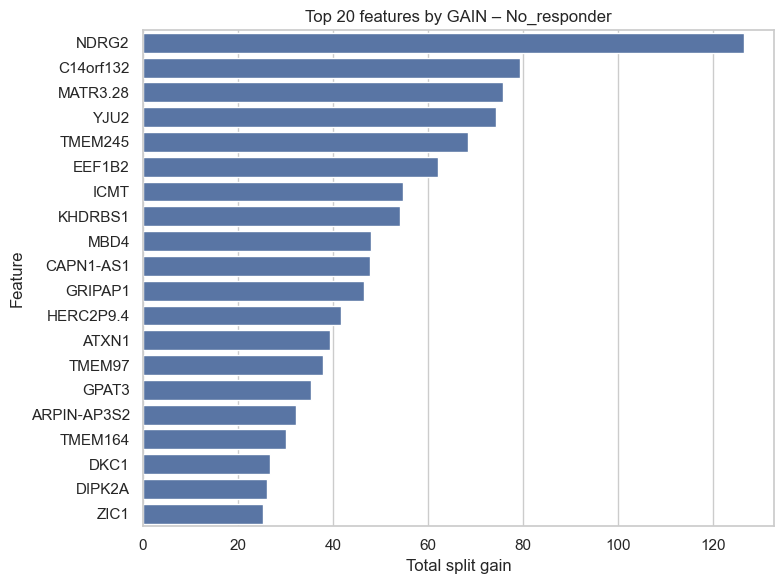

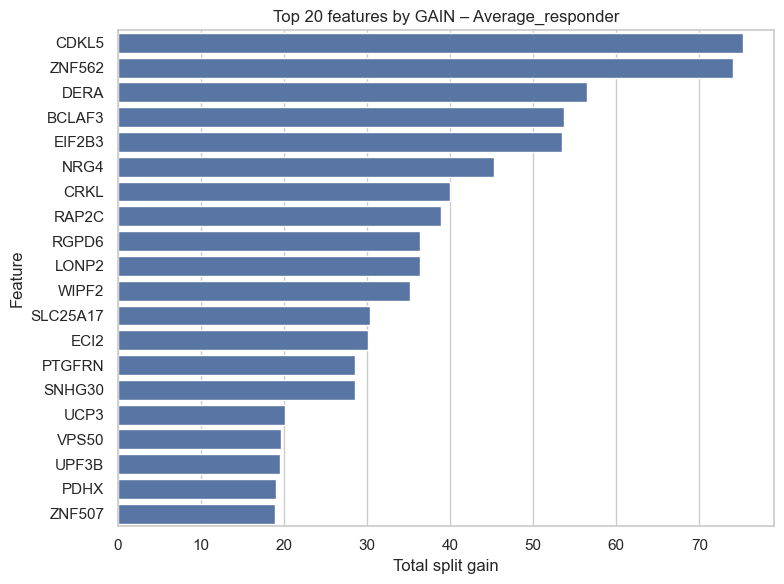

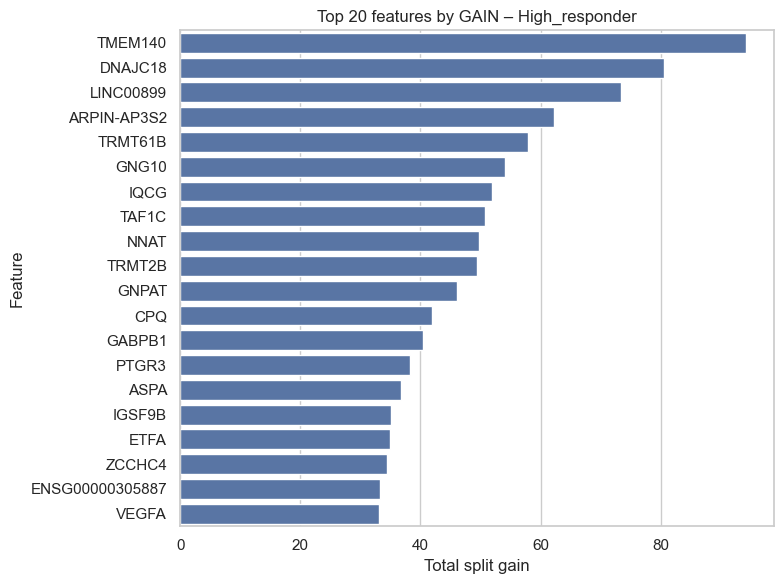

In [294]:
# Trained model: lgbm (sklearn wrapper)
booster = lgbm.booster_
num_class = len(lgbm.classes_)   # should be 3
class_names = ["No_responder", "Average_responder", "High_responder"]

# Extract trees as DataFrame
df_ = booster.trees_to_dataframe()

# Restrict to trees used up to best_iteration
if getattr(lgbm, "best_iteration_", None) is not None:
    df_ = df_[df_["tree_index"] < lgbm.best_iteration_ * num_class]

# Keep only split nodes
df_ = df_[~df_["split_feature"].isna()].copy()

# Map tree
df_["class_id"] = (df_["tree_index"] % num_class).astype(int)

# Aggregate split_gain per (class, feature)
gain_pc = (
    df_.groupby(["class_id", "split_feature"])["split_gain"]
      .sum().reset_index().rename(columns={"split_gain": "gain"})
)

# Plot top-K per class
TOP_K = 20
sns.set(style="whitegrid")
for c in range(num_class):
    data = (gain_pc[gain_pc["class_id"] == c]
            .sort_values("gain", ascending=False).head(TOP_K))
    plt.figure(figsize=(8, max(4, 0.3*len(data))))
    sns.barplot(data=data, y="split_feature", x="gain", color="#4C72B0")
    plt.title(f"Top {TOP_K} features by GAIN – {class_names[c]}")
    plt.xlabel("Total split gain")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


gain_pc["class_name"] = gain_pc["class_id"].map({i:n for i,n in enumerate(class_names)})
gain_pc.sort_values(["class_id","gain"], ascending=[True,False]).to_csv("lgb_per_class_gain.csv", index=False)


## Explanation using shap
Despite using LGBM's inbuilt explanation tool, I still compare it to the one in Shap

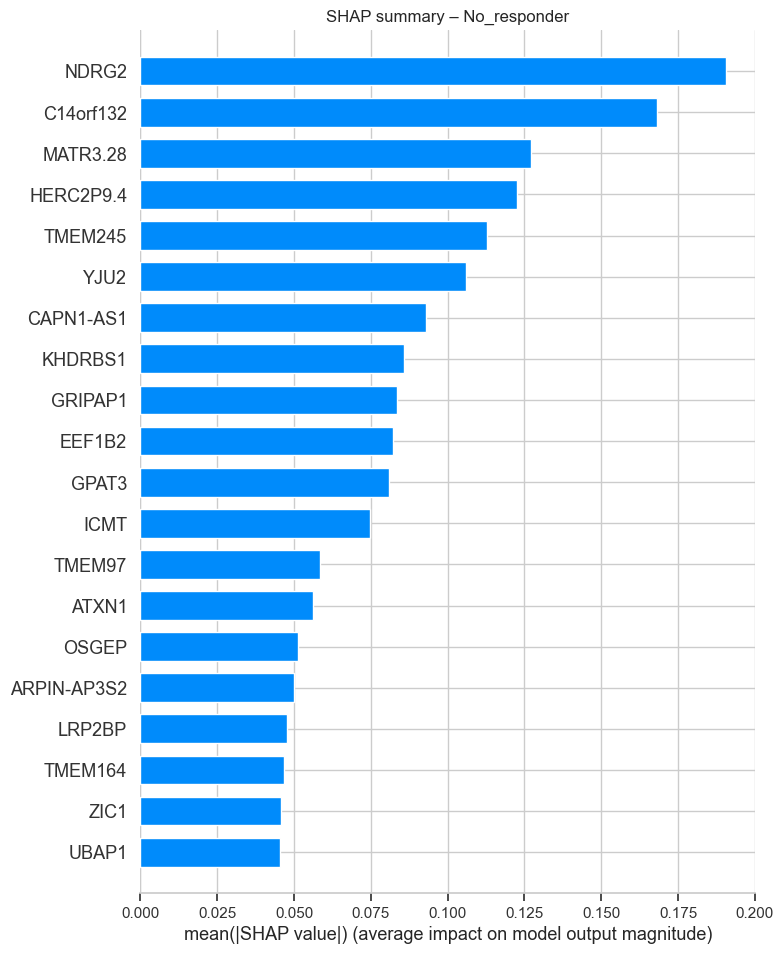

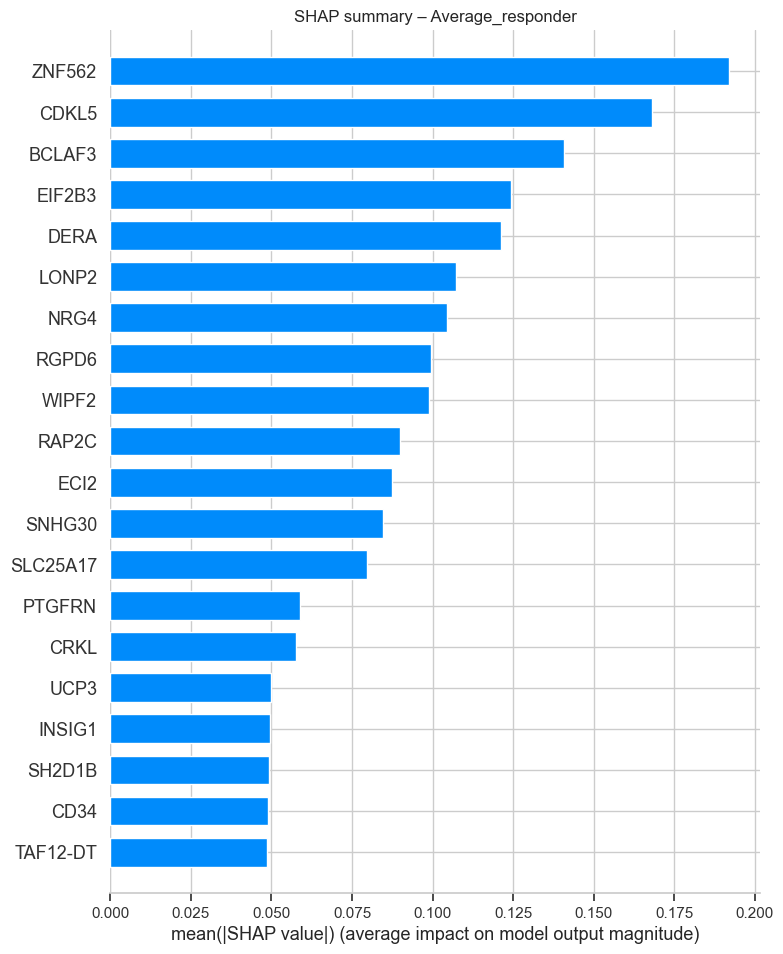

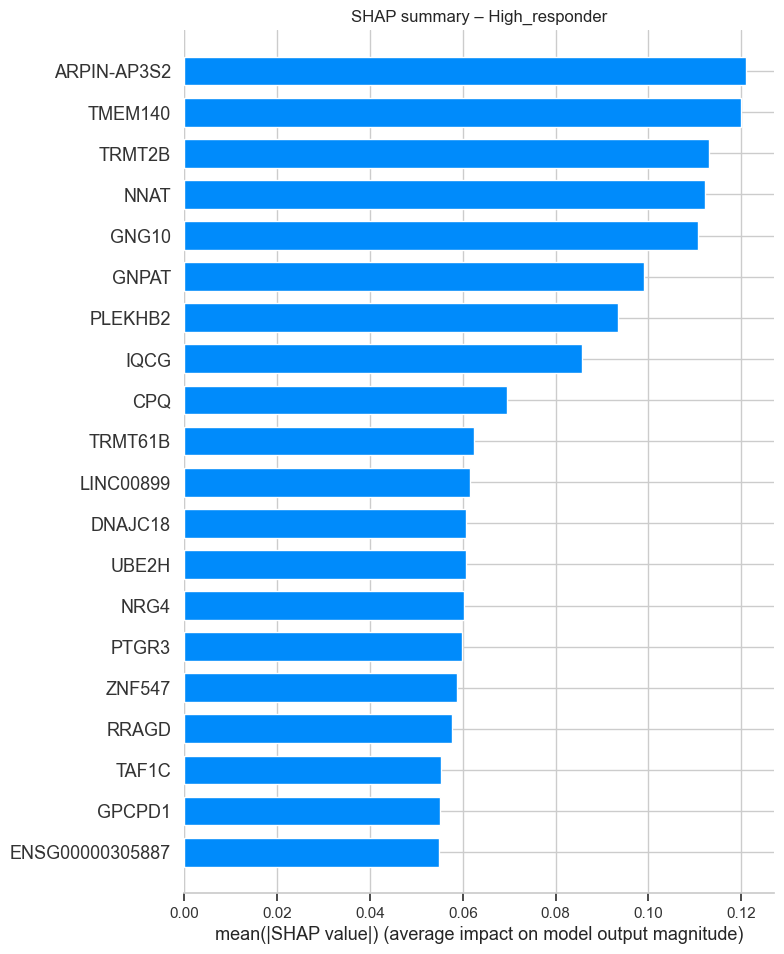

In [318]:


feature_names = lgbm.booster_.feature_name()

explainer = shap.TreeExplainer(lgbm.booster_)
shap_values = explainer.shap_values(X_bg)  # -> (n, d, C) in your setup

for c, name in enumerate(class_names):
    sv_c = shap_values[:, :, c]   # (n, d) for class c
    shap.summary_plot(
        sv_c, X_bg,
        feature_names=feature_names,
        plot_type="bar",      # plot as bar
        max_display=20,       # show top 20 to keep it readable
        show=False
    )
    plt.title(f"SHAP summary – {name}")
    plt.show()



In [330]:
# How many features were relevant for the model
used_features = (lgbm.booster_.feature_importance(importance_type="gain") > 0).sum()
print(f"Features used in splits: {used_features} / {len(lgbm.booster_.feature_name())}")


Features used in splits: 111 / 11231


Extracting the important features as dataframe for saving

In [332]:
#booster = lgbm.booster_
#num_class = len(lgbm.classes_)  # should be 3
#class_names = ["No_responder", "Average_responder", "High_responder"]

# All trees as a DataFrame
#df_trees = booster.trees_to_dataframe()

# IMPORTANT: to respect early stopping we use only trees up to best_iteration_
#if getattr(lgbm, "best_iteration_", None) is not None:
#    df_trees = df_trees[df_trees["tree_index"] < lgbm.best_iteration_ * num_class]

# Keep only split rows (ignore leaves)
#df_splits = df_trees[~df_trees["split_feature"].isna()].copy()

# Map tree -> class: LightGBM cycles trees across classes
#df_splits["class_id"] = (df_splits["tree_index"] % num_class).astype(int)

# Aggregate total split gain per (class, feature)
#gain_pc = (
#    df_splits.groupby(["class_id", "split_feature"])["split_gain"]
#    .sum()
#    .reset_index()
#    .rename(columns={"split_gain": "gain"})
#)

# Long format: one row per (class, feature)
gain_pc["class_name"] = gain_pc["class_id"].map(dict(enumerate(class_names)))
gain_pc = gain_pc.sort_values(["class_id", "gain"], ascending=[True, False]).reset_index(drop=True)
print("\nPer-class gain (long format):")
print(gain_pc.head(15))

# Wide format: one column per class, plus total
df_wide = gain_pc.pivot_table(index="split_feature", columns="class_name", values="gain", fill_value=0)
df_wide["gain_total"] = df_wide.sum(axis=1)
df_wide = df_wide.sort_values("gain_total", ascending=False).reset_index()
df_wide = df_wide.rename(columns={"split_feature": "feature"})
print("\nPer-class gain (wide format):")
print(df_wide.head(15))


# gain_pc.to_csv("lgb_per_class_gain_long.csv", index=False)
# df_wide.to_csv("lgb_per_class_gain_wide.csv", index=False)



Per-class gain (long format):
    class_id split_feature   gain    class_name
0          0         NDRG2 126.48  No_responder
1          0     C14orf132  79.39  No_responder
2          0      MATR3.28  75.71  No_responder
3          0          YJU2  74.24  No_responder
4          0       TMEM245  68.38  No_responder
5          0        EEF1B2  62.13  No_responder
6          0          ICMT  54.80  No_responder
7          0       KHDRBS1  54.15  No_responder
8          0          MBD4  47.99  No_responder
9          0     CAPN1-AS1  47.80  No_responder
10         0       GRIPAP1  46.51  No_responder
11         0     HERC2P9.4  41.63  No_responder
12         0         ATXN1  39.28  No_responder
13         0        TMEM97  37.98  No_responder
14         0         GPAT3  35.44  No_responder

Per-class gain (wide format):
class_name      feature  Average_responder  High_responder  No_responder  \
0                 NDRG2               0.00            0.00        126.48   
1           ARPIN-

In [342]:
# Save files
gain_pc.to_csv("lgb_per_class_gain_long.csv", index=False)
df_wide.to_csv("lgb_per_class_gain_wide.csv", index=False)

In [346]:
# save the LGBM model
joblib.dump(lgbm, "lgbm_model.joblib")

['lgbm_model.joblib']

In [333]:
df_wide

class_name,feature,Average_responder,High_responder,No_responder,gain_total
0,NDRG2,0.00,0.00,126.48,126.48
1,ARPIN-AP3S2,0.00,62.17,32.26,94.42
2,TMEM140,0.00,94.19,0.00,94.19
3,DNAJC18,0.00,80.62,0.00,80.62
4,C14orf132,0.00,0.00,79.39,79.39
...,...,...,...,...,...
106,COX10,0.00,0.00,13.05,13.05
107,DERL1,12.57,0.00,0.00,12.57
108,POLR1C,12.35,0.00,0.00,12.35
109,AHCYL1,12.28,0.00,0.00,12.28


In [341]:
gain_pc

,class_id,split_feature,gain,class_name
0,0,NDRG2,126.48,No_responder
1,0,C14orf132,79.39,No_responder
2,0,MATR3.28,75.71,No_responder
3,0,YJU2,74.24,No_responder
4,0,TMEM245,68.38,No_responder
...,...,...,...,...
109,2,ERI2,20.69,High_responder
110,2,ECHDC2,18.47,High_responder
111,2,CPT1B,18.07,High_responder
112,2,FPGT-TNNI3K,17.88,High_responder


In [343]:
top_no = gain_pc[gain_pc["class_name"] == "No_responder"].sort_values("gain", ascending=False)
#print(top_no.head(30))  # Top 30 features for No_responder by gain
top_no.to_csv("no_responder_genes.csv", index = False)
top_no

,class_id,split_feature,gain,class_name
0,0,NDRG2,126.48,No_responder
1,0,C14orf132,79.39,No_responder
2,0,MATR3.28,75.71,No_responder
3,0,YJU2,74.24,No_responder
4,0,TMEM245,68.38,No_responder
5,0,EEF1B2,62.13,No_responder
6,0,ICMT,54.80,No_responder
7,0,KHDRBS1,54.15,No_responder
8,0,MBD4,47.99,No_responder
9,0,CAPN1-AS1,47.80,No_responder


In [344]:
# Top 30 features for average responders
top_av = gain_pc[gain_pc["class_name"] == "Average_responder"].sort_values("gain", ascending=False)
#print(top_av.head(30))  # Top 30 features for average_responder by gain
top_av.to_csv("average_responder_genes.csv", index = False)
top_av

,class_id,split_feature,gain,class_name
36,1,CDKL5,75.23,Average_responder
37,1,ZNF562,74.05,Average_responder
38,1,DERA,56.43,Average_responder
39,1,BCLAF3,53.70,Average_responder
40,1,EIF2B3,53.51,Average_responder
41,1,NRG4,45.26,Average_responder
42,1,CRKL,40.02,Average_responder
43,1,RAP2C,38.97,Average_responder
44,1,RGPD6,36.46,Average_responder
45,1,LONP2,36.34,Average_responder


In [345]:
# Top 30 features for High responders
top_high = gain_pc[gain_pc["class_name"] == "High_responder"].sort_values("gain", ascending=False)
#print(top_high.head(30))  # Top 30 features for high_responder by gain
top_high.to_csv("high_responder_genes.csv", index = False)
top_high

,class_id,split_feature,gain,class_name
73,2,TMEM140,94.19,High_responder
74,2,DNAJC18,80.62,High_responder
75,2,LINC00899,73.39,High_responder
76,2,ARPIN-AP3S2,62.17,High_responder
77,2,TRMT61B,57.84,High_responder
78,2,GNG10,54.09,High_responder
79,2,IQCG,51.91,High_responder
80,2,TAF1C,50.82,High_responder
81,2,NNAT,49.71,High_responder
82,2,TRMT2B,49.34,High_responder


In [237]:
# Ensemble
#model1 = tf.keras.models.load_model("best_weight_model.keras")
#model2 = tf.keras.models.load_model("best_smote_model.keras")
#model3 = joblib.load("lgbm_model.joblib")

# Get predictions
#pred1 = model1.predict(X_test_scaled)
#pred2 = model2.predict(X_test_scaled)
#pred3 = model3.predict_proba(X_test_scaled)

# Average predictions
#ensemble_pred = (pred1 + pred2 + pred3) / 3
#final_pred = np.argmax(ensemble_pred, axis=1)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [238]:
#print(classification_report(
#    y_test, final_pred,
#    target_names=["No_responder", "Average_responder", "High_responder"],
#    digits=3, zero_division=0
#))

                   precision    recall  f1-score   support

     No_responder      0.250     0.412     0.311        17
Average_responder      0.766     0.742     0.754        66
   High_responder      1.000     0.100     0.182        10

         accuracy                          0.613        93
        macro avg      0.672     0.418     0.416        93
     weighted avg      0.697     0.613     0.611        93

